# MedSAM2 fine-tuning — ground-truth evaluation on held-out cases

Scores a fine-tuned checkpoint against the manually annotated single-frame 3D
volumes under `MedSAM2_finetune_data/processed/`, implementing Step 6 of
`medsam2_function/README.md`.

Metrics come from **MONAI** (`monai.metrics`) — Dice, IoU, average symmetric
surface distance, 95th-percentile Hausdorff, and normalized surface Dice — so
they match the definitions used elsewhere in the medical-imaging literature.
Each case's own `spacing_mm_xyz` is handed to MONAI as `spacing=`, making every
distance a physical millimetre rather than a voxel count; these volumes are
anisotropic (~0.31 × 0.57 × 0.42 mm), so that distinction is not cosmetic.

### What gets reported, and what it means

Cases are graded into three tiers, derived from **which `.npz` files exist in
`npz_train/`** — that folder is the only trustworthy record of what the trainer
actually consumed. (Every `image.json` in the tree says `recommended_split:
"train"`, including cases never trained on, so that field is stale and is
ignored here.)

| tier | meaning | supports a generalization claim? |
|---|---|---|
| `holdout` | the **subject** never appears in `npz_train` | **yes — this is the headline number** |
| `seen_subject` | different bolus of a subject that *was* trained on | weak: same patient, same lesion |
| `train` | this exact case was trained on | no — fit check only |

### Two caveats to carry into any write-up

**1. Every score is prompt-conditional.** `compute_3d_mask()` is a *prompted*
segmenter — it needs a 3D box. In the 4D pipeline that box comes from the
motion-tracked reference VOI; these extracted frames have no tracked bbox, so
the box is derived from the GT mask itself. That measures *segmentation given a
correct box*, not detection, and it is an optimistic setting. The jitter sweep
near the bottom probes how fast that advantage decays.

**2. n = 3 held-out cases, from 2 subjects.** Report per-case numbers, not just
a mean. A 3-case mean has no meaningful confidence interval, and two of the
three cases share a subject (and therefore a lesion).

In [24]:
# ── Setup ────────────────────────────────────────────────────────────────────
# Deliberately does NOT chdir. Paths derive from one absolute anchor, so
# re-running this cell any number of times is a no-op rather than walking the
# working directory a level further up each time.
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

QUANTUS_ROOT = Path("/home/ahmed-el-kaffas/Documents/Github/QuantUS")

MEDSAM2_ROOT = QUANTUS_ROOT / "MedSAM2"
CLI_DEMOS    = QUANTUS_ROOT / "engines" / "ceus" / "CLI-Demos"
FUNCTIONS    = CLI_DEMOS / "medsam2_function"

for path in (MEDSAM2_ROOT, CLI_DEMOS, FUNCTIONS):
    assert path.is_dir(), f"not found: {path}"
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import medsam2_gt_eval as gte

print(f"MedSAM2 root : {MEDSAM2_ROOT}")
print(f"functions    : {FUNCTIONS}")

MedSAM2 root : /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2
functions    : /home/ahmed-el-kaffas/Documents/Github/QuantUS/engines/ceus/CLI-Demos/medsam2_function


In [25]:
# ── Configuration ────────────────────────────────────────────────────────────
FINETUNE_ROOT  = Path("/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data")
PROCESSED_ROOT = FINETUNE_ROOT / "processed"
NPZ_TRAIN_DIR  = FINETUNE_ROOT / "npz_train"     # defines the split — see header

MODEL_CFG = "configs/sam2.1_hiera_t512.yaml"
DEVICE    = "cuda"

# Reconstruction settings — keep these matched to Medsam2AdaptiveBboxMasker's
# defaults so the score reflects what the 4D pipeline actually produces.
PADDING_VOX     = 4
SMOOTH_SIGMA_MM = 1.0

# NSD tolerance, in mm. 1.0 mm lands in a useful range on this data — measured
# NSD sits near 0.5 while Dice is near 0.85, so it separates cases that Dice
# rates similarly. Report the tolerance alongside the number: NSD is meaningless
# without it, and the value should ideally be justified by inter-observer
# variability on these annotations rather than picked for convenience.
TOLERANCE_MM = 1.0

## Cases and split

In [26]:
cases = gte.discover_cases(str(PROCESSED_ROOT), str(NPZ_TRAIN_DIR))

case_df = pd.DataFrame([
    {k: c[k] for k in ("case", "subject_id", "sequence_id", "tier")} for c in cases
])
print(case_df["tier"].value_counts().to_string(), "\n")
display(case_df[case_df.tier != "train"].reset_index(drop=True))

tier
train           14
seen_subject     8
holdout          3 



,case,subject_id,sequence_id,tier
0,subject_000006_sequence_001,subject_000006,sequence_001,holdout
1,subject_000008_sequence_001,subject_000008,sequence_001,holdout
2,subject_000008_sequence_003,subject_000008,sequence_003,holdout
3,subject_000002_sequence_003,subject_000002,sequence_003,seen_subject
4,subject_000004_sequence_002,subject_000004,sequence_002,seen_subject
5,subject_000004_sequence_004,subject_000004,sequence_004,seen_subject
6,subject_000005_sequence_002,subject_000005,sequence_002,seen_subject
7,subject_000009_sequence_002,subject_000009,sequence_002,seen_subject
8,subject_000009_sequence_004,subject_000009,sequence_004,seen_subject
9,subject_000009_sequence_006,subject_000009,sequence_006,seen_subject


## Checkpoints to compare

The baseline matters as much as the fine-tuned run: without a pre-fine-tuning
number on the *same* held-out cases, a Dice of 0.8 is uninterpretable. The
per-epoch checkpoints are what the guide's Step 6 asks you to sweep, since
there is no validation loop wired into the training config and therefore no
automatic "best epoch".

In [27]:
CHECKPOINTS = {
    # label                   path
    "base (MedSAM2)":         MEDSAM2_ROOT / "checkpoints" / "MedSAM2_latest.pt",
    "finetuned ep10":         MEDSAM2_ROOT / "exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint_10.pt",
    "finetuned ep30":         MEDSAM2_ROOT / "exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint_30.pt",
    "finetuned ep50":         MEDSAM2_ROOT / "exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint_50.pt",
}

for label, path in CHECKPOINTS.items():
    print(f"{'OK ' if Path(path).is_file() else 'MISSING'}  {label:<20} {path}")

OK   base (MedSAM2)       /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2/checkpoints/MedSAM2_latest.pt
OK   finetuned ep10       /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2/exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint_10.pt
OK   finetuned ep30       /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2/exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint_30.pt
OK   finetuned ep50       /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2/exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint_50.pt


## Evaluate — held-out tier

In [28]:
TIERS = ("holdout",)

rows = []
for label, path in CHECKPOINTS.items():
    if not Path(path).is_file():
        print(f"skipping missing checkpoint: {label}")
        continue
    rows += gte.evaluate_checkpoint(
        cases, MODEL_CFG, str(path), device=DEVICE, tiers=TIERS,
        padding_vox=PADDING_VOX, smooth_sigma_mm=SMOOTH_SIGMA_MM,
        tolerance_mm=TOLERANCE_MM, label=label,
    )

results = pd.DataFrame(rows)
results.to_csv(FINETUNE_ROOT / "gt_eval_holdout.csv", index=False)
print(f"\n{len(results)} rows -> {FINETUNE_ROOT / 'gt_eval_holdout.csv'}")


=== base (MedSAM2) — 3 case(s) from tiers ('holdout',) ===
  subject_000006_sequence_001        dice=0.757  nsd=0.196  assd=2.32mm  hd95=6.81mm
  subject_000008_sequence_001        dice=0.849  nsd=0.546  assd=1.15mm  hd95=3.36mm
  subject_000008_sequence_003        dice=0.734  nsd=0.343  assd=1.75mm  hd95=4.66mm

=== finetuned ep10 — 3 case(s) from tiers ('holdout',) ===
  subject_000006_sequence_001        dice=0.774  nsd=0.235  assd=2.08mm  hd95=6.48mm
  subject_000008_sequence_001        dice=0.788  nsd=0.293  assd=1.77mm  hd95=5.06mm
  subject_000008_sequence_003        dice=0.688  nsd=0.124  assd=2.09mm  hd95=4.94mm

=== finetuned ep30 — 3 case(s) from tiers ('holdout',) ===
  subject_000006_sequence_001        dice=0.865  nsd=0.470  assd=1.20mm  hd95=3.17mm
  subject_000008_sequence_001        dice=0.855  nsd=0.491  assd=1.08mm  hd95=2.73mm
  subject_000008_sequence_003        dice=0.809  nsd=0.509  assd=1.17mm  hd95=3.58mm

=== finetuned ep50 — 3 case(s) from tiers ('holdout',)

In [29]:
# ── Per-case detail ──────────────────────────────────────────────────────────
# With n=3 the individual values carry the information; a mean alone would hide
# a single catastrophic case behind two good ones.
nsd_col = f"nsd@{TOLERANCE_MM}mm"
metric_cols = ["dice", "iou", nsd_col, "assd_mm", "hd95_mm", "vol_ratio"]

display(
    results.pivot_table(index="case", columns="checkpoint", values="dice")
           .style.format("{:.3f}").set_caption("Dice per case")
)
display(results[["checkpoint", "case", *metric_cols, "empty_pred"]].round(3))

checkpoint,base (MedSAM2),finetuned ep10,finetuned ep30,finetuned ep50
case,,,,
subject_000006_sequence_001,0.757,0.774,0.865,0.877
subject_000008_sequence_001,0.849,0.788,0.855,0.849
subject_000008_sequence_003,0.734,0.688,0.809,0.809


,checkpoint,case,dice,iou,nsd@1.0mm,assd_mm,hd95_mm,vol_ratio,empty_pred
0,base (MedSAM2),subject_000006_sequence_001,0.757,0.608,0.196,2.318,6.808,1.581,False
1,base (MedSAM2),subject_000008_sequence_001,0.849,0.738,0.546,1.151,3.363,1.038,False
2,base (MedSAM2),subject_000008_sequence_003,0.734,0.580,0.343,1.750,4.659,1.657,False
3,finetuned ep10,subject_000006_sequence_001,0.774,0.632,0.235,2.082,6.477,1.550,False
4,finetuned ep10,subject_000008_sequence_001,0.788,0.650,0.293,1.774,5.063,1.480,False
5,finetuned ep10,subject_000008_sequence_003,0.688,0.525,0.124,2.088,4.935,1.903,False
6,finetuned ep30,subject_000006_sequence_001,0.865,0.762,0.470,1.198,3.169,1.035,False
7,finetuned ep30,subject_000008_sequence_001,0.855,0.747,0.491,1.079,2.731,0.942,False
8,finetuned ep30,subject_000008_sequence_003,0.809,0.679,0.509,1.169,3.580,1.326,False
9,finetuned ep50,subject_000006_sequence_001,0.877,0.781,0.524,1.120,3.281,0.996,False


In [30]:
# ── Aggregate ────────────────────────────────────────────────────────────────
agg = (results.groupby("checkpoint")[metric_cols]
              .agg(["mean", "std"])
              .round(3))
# preserve the order CHECKPOINTS was declared in, not alphabetical
agg = agg.reindex([c for c in CHECKPOINTS if c in agg.index])
display(agg)

if results["empty_pred"].any():
    failed = results[results.empty_pred][["checkpoint", "case"]]
    print("\nEmpty predictions (surface metrics are NaN for these):")
    print(failed.to_string(index=False))

dice           iou        nsd@1.0mm        assd_mm         \
                 mean    std   mean    std      mean    std    mean    std   
checkpoint                                                                   
base (MedSAM2)  0.780  0.061  0.642  0.084     0.362  0.176   1.740  0.583   
finetuned ep10  0.750  0.054  0.602  0.068     0.217  0.086   1.982  0.180   
finetuned ep30  0.843  0.030  0.730  0.044     0.490  0.020   1.149  0.062   
finetuned ep50  0.845  0.034  0.733  0.051     0.519  0.012   1.126  0.036   

               hd95_mm        vol_ratio         
                  mean    std      mean    std  
checkpoint                                      
base (MedSAM2)   4.943  1.740     1.425  0.337  
finetuned ep10   5.492  0.856     1.644  0.227  
finetuned ep30   3.160  0.425     1.101  0.200  
finetuned ep50   3.295  0.119     1.026  0.193

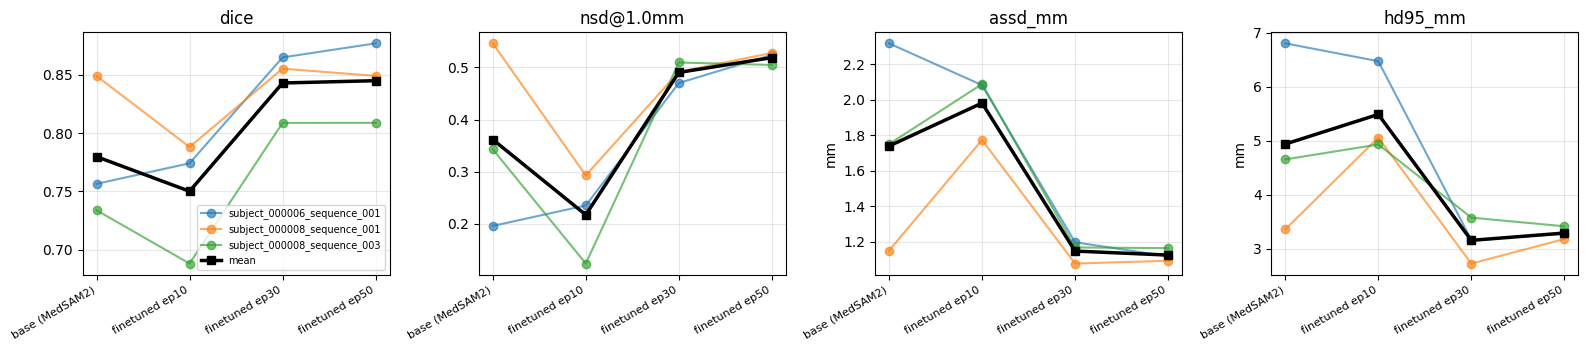

In [31]:
# ── Metric vs. checkpoint ────────────────────────────────────────────────────
plot_metrics = ["dice", nsd_col, "assd_mm", "hd95_mm"]
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 3.6))

order = [c for c in CHECKPOINTS if c in results.checkpoint.unique()]
x = np.arange(len(order))

for ax, metric in zip(axes, plot_metrics):
    # one line per case, so a checkpoint that helps one case and wrecks another
    # is visible rather than averaged away
    for case, grp in results.groupby("case"):
        grp = grp.set_index("checkpoint").reindex(order)
        ax.plot(x, grp[metric], marker="o", alpha=0.65, label=case)
    means = [results[results.checkpoint == c][metric].mean() for c in order]
    ax.plot(x, means, color="k", linewidth=2.5, marker="s", label="mean")

    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
    ax.set_title(metric)
    ax.grid(alpha=0.3)
    if metric.endswith("_mm"):
        ax.set_ylabel("mm")

axes[0].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## Prompt sensitivity

The box above was derived from the GT mask, so these scores are the optimistic
end of the range. Jittering each box face by a few voxels approximates a box
that came from imperfect tracking instead — the slope of this curve tells you
how much of the performance is the model and how much was handed to it by the
prompt. A model whose Dice collapses at 8 voxels of jitter will not survive
contact with the tracked bbox in the 4D pipeline.

jitter  0 vox — dice 0.845 (per case: 0.877, 0.849, 0.809)
jitter  2 vox — dice 0.845 (per case: 0.874, 0.846, 0.816)
jitter  4 vox — dice 0.834 (per case: 0.860, 0.829, 0.814)
jitter  8 vox — dice 0.799 (per case: 0.845, 0.765, 0.786)


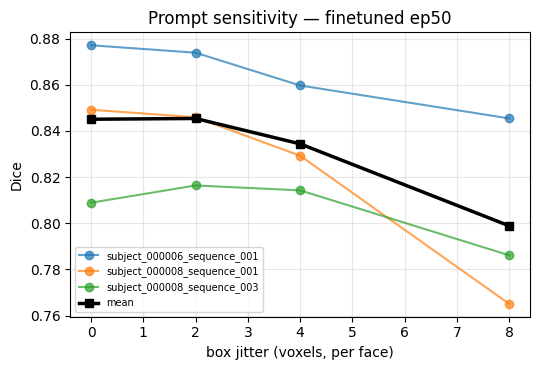

In [32]:
JITTER_SWEEP = [0, 2, 4, 8]
BEST_CHECKPOINT = "finetuned ep50"      # set to whichever won above

jitter_rows = []
for jitter in JITTER_SWEEP:
    batch = gte.evaluate_checkpoint(
        cases, MODEL_CFG, str(CHECKPOINTS[BEST_CHECKPOINT]), device=DEVICE,
        tiers=TIERS, padding_vox=PADDING_VOX, jitter_vox=jitter,
        smooth_sigma_mm=SMOOTH_SIGMA_MM, tolerance_mm=TOLERANCE_MM,
        label=f"jitter={jitter}", seed=0, verbose=False,
    )
    for row in batch:
        row["jitter_vox"] = jitter
    jitter_rows += batch
    dices = [r["dice"] for r in batch]
    print(f"jitter {jitter:>2} vox — dice {np.mean(dices):.3f} "
          f"(per case: {', '.join(f'{d:.3f}' for d in dices)})")

jitter_df = pd.DataFrame(jitter_rows)

fig, ax = plt.subplots(figsize=(5.5, 3.8))
for case, grp in jitter_df.groupby("case"):
    grp = grp.sort_values("jitter_vox")
    ax.plot(grp.jitter_vox, grp.dice, marker="o", alpha=0.7, label=case)
ax.plot(jitter_df.groupby("jitter_vox").dice.mean(), color="k", lw=2.5, marker="s", label="mean")
ax.set_xlabel("box jitter (voxels, per face)")
ax.set_ylabel("Dice")
ax.set_title(f"Prompt sensitivity — {BEST_CHECKPOINT}")
ax.grid(alpha=0.3)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Qualitative check

Metrics hide failure *modes*. This shows the GT contour against the prediction
on the mask's central axial slice for every held-out case, which is where an
over-segmentation into adjacent liver, or a mask that collapsed to the box, is
immediately obvious.

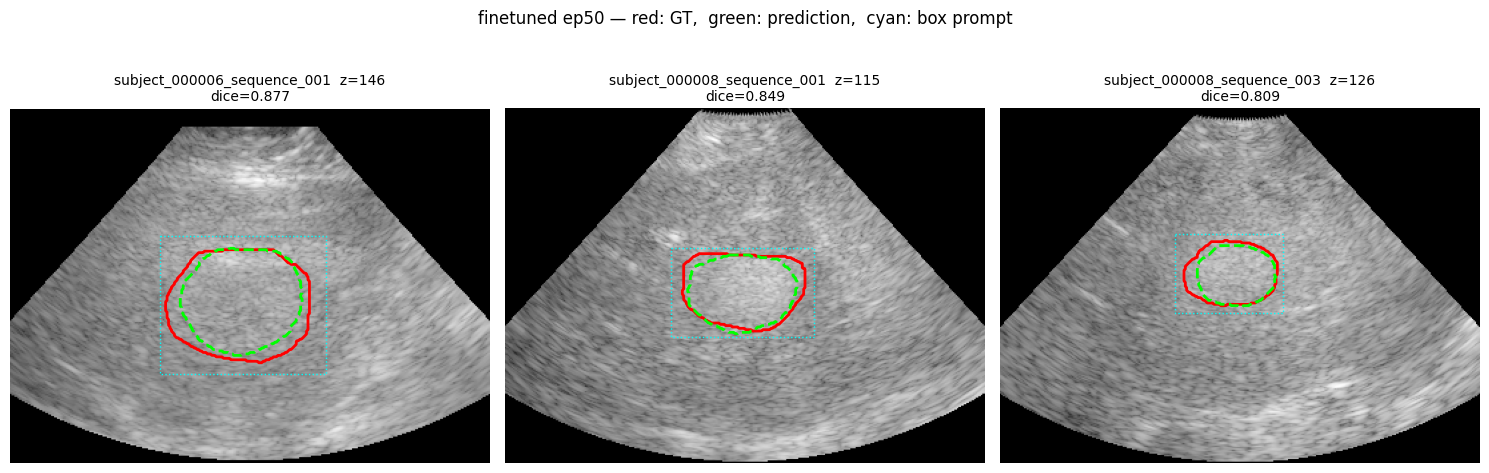

In [33]:
QUALITATIVE_CHECKPOINT = BEST_CHECKPOINT

predictor = gte.build_predictor(MODEL_CFG, str(CHECKPOINTS[QUALITATIVE_CHECKPOINT]), device=DEVICE)
holdout = [c for c in cases if c["tier"] == "holdout"]

fig, axes = plt.subplots(1, len(holdout), figsize=(5 * len(holdout), 5))
axes = np.atleast_1d(axes)

for ax, case in zip(axes, holdout):
    volume, gt, spacing, _ = gte.load_case(case)
    pred, bbox = gte.predict_case(
        predictor, volume, gt, padding_vox=PADDING_VOX,
        spacing=spacing, smooth_sigma_mm=SMOOTH_SIGMA_MM,
    )

    z = int(np.argmax(gt.sum(axis=(0, 1))))          # slice with the most tumour
    ax.imshow(volume[:, :, z].T, cmap="gray")
    ax.contour(gt[:, :, z].T, colors="red", linewidths=2)
    ax.contour(pred[:, :, z].T, colors="lime", linewidths=2, linestyles="dashed")
    ax.add_patch(plt.Rectangle(
        (bbox.x_min, bbox.y_min), bbox.x_max - bbox.x_min, bbox.y_max - bbox.y_min,
        edgecolor="cyan", facecolor="none", linewidth=1, linestyle=":",
    ))
    ax.set_title(f"{case['case']}  z={z}\ndice={gte.dice(pred, gt):.3f}", fontsize=10)
    ax.axis("off")

fig.suptitle(f"{QUALITATIVE_CHECKPOINT} — red: GT,  green: prediction,  cyan: box prompt", y=1.02)
plt.tight_layout()
plt.show()

gte._free(predictor)

## Optional — other tiers

`seen_subject` shows whether the model handles a new bolus of a lesion it has
already seen; it is a genuinely easier task than `holdout`, so keep the two
numbers separate rather than pooling them. `train` is a fit check: a low score
there means training did not converge, while a high score says nothing about
generalization.

In [34]:
OTHER_TIERS = ("seen_subject",)     # add "train" for the fit check

other_rows = gte.evaluate_checkpoint(
    cases, MODEL_CFG, str(CHECKPOINTS[BEST_CHECKPOINT]), device=DEVICE,
    tiers=OTHER_TIERS, padding_vox=PADDING_VOX, smooth_sigma_mm=SMOOTH_SIGMA_MM,
    tolerance_mm=TOLERANCE_MM, label=BEST_CHECKPOINT,
)

other_df = pd.DataFrame(other_rows)
combined = pd.concat([results[results.checkpoint == BEST_CHECKPOINT], other_df])

display(combined.groupby("tier")[metric_cols].agg(["mean", "std"]).round(3))
display(other_df[["case", *metric_cols]].round(3))


=== finetuned ep50 — 8 case(s) from tiers ('seen_subject',) ===
  subject_000002_sequence_003        dice=0.784  nsd=0.173  assd=3.70mm  hd95=13.35mm
  subject_000004_sequence_002        dice=0.816  nsd=0.492  assd=1.36mm  hd95=3.99mm
  subject_000004_sequence_004        dice=0.790  nsd=0.527  assd=1.54mm  hd95=6.49mm
  subject_000005_sequence_002        dice=0.840  nsd=0.554  assd=1.14mm  hd95=3.22mm
  subject_000009_sequence_002        dice=0.822  nsd=0.464  assd=1.11mm  hd95=2.57mm
  subject_000009_sequence_004        dice=0.838  nsd=0.541  assd=1.08mm  hd95=2.95mm
  subject_000009_sequence_006        dice=0.802  nsd=0.550  assd=1.11mm  hd95=3.49mm
  subject_000010_sequence_002        dice=0.720  nsd=0.547  assd=1.13mm  hd95=3.28mm


dice           iou        nsd@1.0mm        assd_mm         \
               mean    std   mean    std      mean    std    mean    std   
tier                                                                       
holdout       0.845  0.034  0.733  0.051     0.519  0.012   1.126  0.036   
seen_subject  0.801  0.039  0.670  0.052     0.481  0.128   1.521  0.893   

             hd95_mm        vol_ratio         
                mean    std      mean    std  
tier                                          
holdout        3.295  0.119     1.026  0.193  
seen_subject   4.917  3.615     1.234  0.235

,case,dice,iou,nsd@1.0mm,assd_mm,hd95_mm,vol_ratio
0,subject_000002_sequence_003,0.784,0.645,0.173,3.696,13.352,0.859
1,subject_000004_sequence_002,0.816,0.690,0.492,1.361,3.990,1.394
2,subject_000004_sequence_004,0.790,0.652,0.527,1.542,6.488,1.231
3,subject_000005_sequence_002,0.840,0.724,0.554,1.136,3.217,1.086
4,subject_000009_sequence_002,0.822,0.697,0.464,1.114,2.568,1.196
5,subject_000009_sequence_004,0.838,0.721,0.541,1.081,2.949,1.134
6,subject_000009_sequence_006,0.802,0.669,0.550,1.113,3.494,1.312
7,subject_000010_sequence_002,0.720,0.562,0.547,1.128,3.276,1.658
